In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

In [5]:
url = "https://www.bikewale.com/new-bike-search/"

response = requests.get(url)

print(response.status_code)

200


In [6]:
print(response.text[:1000])

<!DOCTYPE html><html lang="en" itemscope itemtype="http://schema.org/WebPage" prefix="og: http://ogp.me/ns# fb: http://ogp.me/ns/fb#"><head><link rel="preload" href="https://stc.aeplcdn.com/fonts/lato-bold.woff2" as="font" type="font/woff2" crossorigin><link rel="preload" href="https://stc.aeplcdn.com/fonts/lato-regular.woff2" as="font" type="font/woff2" crossorigin><link rel="manifest" href="/manifest.webmanifest.json">
    <title data-react-helmet="true" itemprop="name">Search New Bikes by Brand, Budget, Mileage and Ride Style - BikeWale</title>
    
    <link data-chunk="main-desktop" rel="preload" as="style" href="https://stb.aeplcdn.com/bikewale/UI/pwa/client-build-modern/css/main-desktop-e96e9bea.75d38da35a70df5a5fd4.css">


<link href="https://imgd.aeplcdn.com" rel="preconnect dns-prefetch" crossorigin><link href="https://stc.aeplcdn.com" rel="preconnect dns-prefetch" crossorigin><link href="https://stb.aeplcdn.com" rel="preconnect dns-prefetch" crossorigin><link href="https://w

In [7]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.get_text(strip=True))

Search New Bikes by Brand, Budget, Mileage and Ride Style - BikeWale


In [8]:
# Find all links on the page
links = soup.find_all("a")

print("Total links:", len(links))

Total links: 157


In [9]:
for link in links[:20]:
    print(link.get_text(" ", strip=True))


Bajaj Pulsar N160 2V
TVS Raider 125
TVS Ronin
Royal Enfield Himalayan 440
TVS iQube
Royal Enfield Hunter 350
Honda SP 125
Royal Enfield Classic 350
Royal Enfield Bullet 350
Jawa All Stars 42 Bobber
TVS Apache RTR 160
Jawa All Star 42
Hero Xtreme 125R
Yamaha MT 15 V2
TVS Jupiter 125
Royal Enfield Continental GT 650
Yamaha R15 V4
Bajaj Pulsar NS400Z
TVS Jupiter


In [10]:
for link in links[:20]:
    name = link.get_text(" ", strip=True)
    href = link.get("href")
    
    if name:
        print(name, "→", href)

Bajaj Pulsar N160 2V → /bajaj-bikes/pulsar-n160/
TVS Raider 125 → /tvs-bikes/raider-125/
TVS Ronin → /tvs-bikes/ronin/
Royal Enfield Himalayan 440 → /royalenfield-bikes/himalayan-440/
TVS iQube → /tvs-bikes/iqube/
Royal Enfield Hunter 350 → /royalenfield-bikes/hunter-350/
Honda SP 125 → /honda-bikes/sp-125/
Royal Enfield Classic 350 → /royalenfield-bikes/classic-350/
Royal Enfield Bullet 350 → /royalenfield-bikes/bullet/
Jawa All Stars 42 Bobber → /jawa-bikes/all-stars-42-bobber/
TVS Apache RTR 160 → /tvs-bikes/apache-160/
Jawa All Star 42 → /jawa-bikes/all-star-42/
Hero Xtreme 125R → /hero-bikes/xtreme-125r/
Yamaha MT 15 V2 → /yamaha-bikes/mt-15/
TVS Jupiter 125 → /tvs-bikes/jupiter-125/
Royal Enfield Continental GT 650 → /royalenfield-bikes/continental-gt-650/
Yamaha R15 V4 → /yamaha-bikes/r15/
Bajaj Pulsar NS400Z → /bajaj-bikes/pulsar-ns400z/
TVS Jupiter → /tvs-bikes/jupiter/


In [11]:
base_url = "https://www.bikewale.com"

for link in links[:5]:
    name = link.get_text(" ", strip=True)
    href = link.get("href")
    
    if name and href:
        full_url = base_url + href
        print(name, "→", full_url)

Bajaj Pulsar N160 2V → https://www.bikewale.com/bajaj-bikes/pulsar-n160/
TVS Raider 125 → https://www.bikewale.com/tvs-bikes/raider-125/
TVS Ronin → https://www.bikewale.com/tvs-bikes/ronin/
Royal Enfield Himalayan 440 → https://www.bikewale.com/royalenfield-bikes/himalayan-440/


In [12]:
bike_url = "https://www.bikewale.com/bajaj-bikes/pulsar-n160/"

bike_response = requests.get(bike_url)

print(bike_response.status_code)

200


In [13]:
bike_soup = BeautifulSoup(bike_response.text, "html.parser")

print(bike_soup.title.get_text(strip=True))

Bajaj Pulsar N160 2V Price - Mileage, Images, Colours | BikeWale


In [14]:
text = bike_soup.get_text(" ", strip=True)

print(text[:3000])

Bajaj Pulsar N160 2V Price - Mileage, Images, Colours | BikeWale Log In AD Bajaj Pulsar N160 2V 1277 Ratings Write Review Compare Overview Price Expert Opinion Similar Street Bikes Colours Mileage Specs & Features User Reviews News Videos Mileage - ARAI 51.6 kmpl Good Kerb Weight 148 kg Good Seat Height 795 mm Good Aggressive front end with LED headlight is modern and attention grabbing. Disc brakes at both front and rear, with dual channel ABS for added safety. High variants come with upside down forks, which provide better handling and stability. Colours Images Videos Variant SD Single Seat - USD City Show price in my city ₹ 1,22,990 Check on-road price Avg. Ex-Showroom price Get September Offers Contact Bajaj Get in touch with Bajaj for best offers, test rides, EMI options, exchange benefits and much more... Get Buying Assistance Variants (3) New SD Single Seat - USD TD Single Seat - USD TD Split Seat - USD Compare Compare Compare Bajaj Pulsar N160 2V Price Variants (3) New Pulsar N

In [15]:
engine = re.search(r'Engine Capacity\s+([\d.]+)\s+cc', text)

print(engine.group(1))

164.82


In [16]:
mileage = re.search(r'Mileage - ARAI\s+([\d.]+)\s+kmpl', text)

print(mileage.group(1))

51.6


In [17]:
power = re.search(r'Power\s+([\d.]+)\s+bhp', text)

print(power.group(1))

15.68


In [18]:
price = re.search(r'₹\s*([\d,]+)', text)

print(price.group(1))

1,22,990


In [19]:
weight = re.search(r'Kerb Weight\s+([\d.]+)\s+kg', text)

print(weight.group(1))

148


In [20]:
bike_data = {
    "Bike_Name": "Bajaj Pulsar N160 2V",
    "Engine_CC": 164.82,
    "Mileage_KMPL": 51.6,
    "Weight_KG": 148
}

print(bike_data)

{'Bike_Name': 'Bajaj Pulsar N160 2V', 'Engine_CC': 164.82, 'Mileage_KMPL': 51.6, 'Weight_KG': 148}


In [21]:
engine = re.search(r'Engine Capacity\s+([\d.]+)\s+cc', text)
mileage = re.search(r'Mileage - ARAI\s+([\d.]+)\s+kmpl', text)
weight = re.search(r'Kerb Weight\s+([\d.]+)\s+kg', text)
price = re.search(r'₹\s*([\d,]+)', text)

print("Engine:", engine.group(1))
print("Mileage:", mileage.group(1))
print("Weight:", weight.group(1))
print("Price:", price.group(1))

Engine: 164.82
Mileage: 51.6
Weight: 148
Price: 1,22,990


In [22]:
price_value = int(price.group(1).replace(",", ""))

print(price_value)

122990


In [23]:
bike_data = {
    "Bike_Name": "Bajaj Pulsar N160 2V",
    "Engine_CC": float(engine.group(1)),
    "Mileage_KMPL": float(mileage.group(1)),
    "Weight_KG": float(weight.group(1)),
    "Price": price_value
}

print(bike_data)

{'Bike_Name': 'Bajaj Pulsar N160 2V', 'Engine_CC': 164.82, 'Mileage_KMPL': 51.6, 'Weight_KG': 148.0, 'Price': 122990}


In [24]:
bike_name = bike_soup.title.get_text(strip=True)

bike_name = bike_name.split(" Price")[0]

print(bike_name)

Bajaj Pulsar N160 2V


In [25]:
bike_data = {
    "Bike_Name": bike_name,
    "Engine_CC": float(engine.group(1)),
    "Mileage_KMPL": float(mileage.group(1)),
    "Weight_KG": float(weight.group(1)),
    "Price": price_value
}

print(bike_data)

{'Bike_Name': 'Bajaj Pulsar N160 2V', 'Engine_CC': 164.82, 'Mileage_KMPL': 51.6, 'Weight_KG': 148.0, 'Price': 122990}


In [26]:
df = pd.DataFrame([bike_data])

print(df)

              Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG   Price
0  Bajaj Pulsar N160 2V     164.82          51.6      148.0  122990


In [27]:
print(df.dtypes)

Bike_Name        object
Engine_CC       float64
Mileage_KMPL    float64
Weight_KG       float64
Price             int64
dtype: object


In [28]:
print(text[:500])

Bajaj Pulsar N160 2V Price - Mileage, Images, Colours | BikeWale Log In AD Bajaj Pulsar N160 2V 1277 Ratings Write Review Compare Overview Price Expert Opinion Similar Street Bikes Colours Mileage Specs & Features User Reviews News Videos Mileage - ARAI 51.6 kmpl Good Kerb Weight 148 kg Good Seat Height 795 mm Good Aggressive front end with LED headlight is modern and attention grabbing. Disc brakes at both front and rear, with dual channel ABS for added safety. High variants come with upside do


In [29]:
ratings_count = re.search(r'([\d,]+)\s+Ratings', text)

print(ratings_count.group(1))

1277


In [30]:
print("4.6" in bike_response.text)

True


In [31]:
position = bike_response.text.find("4.6")

print(position)
print(bike_response.text[position-300:position+300])

6256
 2 engine and has a  expert reported mileage of 51.6 kmpl. With both front and rear disc brakes, the Bajaj Pulsar N160 2V comes with anti-locking braking system. The Pulsar N160 2V bike weighs 148 kg and has a fuel tank capacity of 14 liters. It develops a power output of 15.68 bhp and a torque of 14.65 Nm.","name":"Bajaj Pulsar N160 2V","image":[{"@type":"ImageObject","url":"https://imgd.aeplcdn.com/1280x720/n/cw/ec/1/versions/--sd-single-seat-usd1788761059440.jpg","width":"1280","height":"720"},{"@type":"ImageObject","url":"https://imgd.aeplcdn.com/1280x720/n/cw/ec/124645/pulsar-n160-right-s


In [32]:
power = re.search(r'power output of ([\d.]+)\s+bhp', bike_response.text)

print(power.group(1))

15.68


In [33]:
bike_data["Power_BHP"] = float(power.group(1))
bike_data["Ratings_Count"] = int(ratings_count.group(1).replace(",", ""))

df = pd.DataFrame([bike_data])

print(df)

              Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG   Price  \
0  Bajaj Pulsar N160 2V     164.82          51.6      148.0  122990   

   Power_BHP  Ratings_Count  
0      15.68           1277  


In [34]:
def scrape_bike(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    # Bike name
    bike_name = soup.title.get_text(strip=True)
    bike_name = bike_name.split(" Price")[0]

    # Engine
    engine = re.search(r'Engine Capacity\s+([\d.]+)\s+cc', text)

    # Mileage
    mileage = re.search(r'Mileage - ARAI\s+([\d.]+)\s+kmpl', text)

    # Weight
    weight = re.search(r'Kerb Weight\s+([\d.]+)\s+kg', text)

    # Price
    price = re.search(r'₹\s*([\d,]+)', text)

    # Power
    power = re.search(r'power output of ([\d.]+)\s+bhp', response.text)

    # Ratings count
    ratings_count = re.search(r'([\d,]+)\s+Ratings', text)

    return {
        "Bike_Name": bike_name,
        "Engine_CC": float(engine.group(1)) if engine else None,
        "Mileage_KMPL": float(mileage.group(1)) if mileage else None,
        "Weight_KG": float(weight.group(1)) if weight else None,
        "Price": int(price.group(1).replace(",", "")) if price else None,
        "Power_BHP": float(power.group(1)) if power else None,
        "Ratings_Count": int(ratings_count.group(1).replace(",", "")) if ratings_count else None
    }

In [35]:
test_bike = scrape_bike(
    "https://www.bikewale.com/bajaj-bikes/pulsar-n160/"
)

print(test_bike)

{'Bike_Name': 'Bajaj Pulsar N160 2V', 'Engine_CC': 164.82, 'Mileage_KMPL': 51.6, 'Weight_KG': 148.0, 'Price': 122990, 'Power_BHP': 15.68, 'Ratings_Count': 1277}


In [36]:
bike_urls = [
    "https://www.bikewale.com/bajaj-bikes/pulsar-n160/",
    "https://www.bikewale.com/tvs-bikes/raider-125/",
    "https://www.bikewale.com/tvs-bikes/ronin/",
    "https://www.bikewale.com/royalenfield-bikes/himalayan-440/",
    "https://www.bikewale.com/royalenfield-bikes/bullet/"
]

for url in bike_urls:
    data = scrape_bike(url)
    print(data)

{'Bike_Name': 'Bajaj Pulsar N160 2V', 'Engine_CC': 164.82, 'Mileage_KMPL': 51.6, 'Weight_KG': 148.0, 'Price': 122990, 'Power_BHP': 15.68, 'Ratings_Count': 1277}
{'Bike_Name': 'TVS Raider 125', 'Engine_CC': 124.8, 'Mileage_KMPL': 56.7, 'Weight_KG': 123.0, 'Price': 86397, 'Power_BHP': 11.2, 'Ratings_Count': 2955}
{'Bike_Name': 'TVS Ronin', 'Engine_CC': 225.9, 'Mileage_KMPL': 42.0, 'Weight_KG': 160.0, 'Price': 130314, 'Power_BHP': 20.1, 'Ratings_Count': 1154}
{'Bike_Name': 'Royal Enfield Himalayan 440', 'Engine_CC': 443.0, 'Mileage_KMPL': None, 'Weight_KG': 199.0, 'Price': 229000, 'Power_BHP': 25.4, 'Ratings_Count': 18}
{'Bike_Name': 'Royal Enfield Bullet 350', 'Engine_CC': 349.0, 'Mileage_KMPL': None, 'Weight_KG': 195.0, 'Price': 165656, 'Power_BHP': 20.2, 'Ratings_Count': 1569}


In [37]:
all_bikes = []

for url in bike_urls:
    data = scrape_bike(url)
    all_bikes.append(data)

df = pd.DataFrame(all_bikes)

print(df)

                     Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG   Price  \
0         Bajaj Pulsar N160 2V     164.82          51.6      148.0  122990   
1               TVS Raider 125     124.80          56.7      123.0   86397   
2                    TVS Ronin     225.90          42.0      160.0  130314   
3  Royal Enfield Himalayan 440     443.00           NaN      199.0  229000   
4     Royal Enfield Bullet 350     349.00           NaN      195.0  165656   

   Power_BHP  Ratings_Count  
0      15.68           1277  
1      11.20           2955  
2      20.10           1154  
3      25.40             18  
4      20.20           1569  


In [38]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (5, 7)

Columns:
Index(['Bike_Name', 'Engine_CC', 'Mileage_KMPL', 'Weight_KG', 'Price',
       'Power_BHP', 'Ratings_Count'],
      dtype='object')

Data Types:
Bike_Name         object
Engine_CC        float64
Mileage_KMPL     float64
Weight_KG        float64
Price              int64
Power_BHP        float64
Ratings_Count      int64
dtype: object

Missing Values:
Bike_Name        0
Engine_CC        0
Mileage_KMPL     2
Weight_KG        0
Price            0
Power_BHP        0
Ratings_Count    0
dtype: int64


In [39]:
bike_links = []

for link in links:
    href = link.get("href")
    name = link.get_text(" ", strip=True)

    if href and name and "/bikes/" in href:
        full_url = base_url + href
        bike_links.append(full_url)

# Remove duplicate URLs
bike_links = list(dict.fromkeys(bike_links))

print("Total bike URLs found:", len(bike_links))
print("\nFirst 10 bike URLs:")

for url in bike_links[:10]:
    print(url)

Total bike URLs found: 0

First 10 bike URLs:


In [40]:
bike_links = []

for link in links:
    href = link.get("href")
    name = link.get_text(" ", strip=True)

    if href and name and href.endswith("/") and "-bikes/" in href:
        full_url = base_url + href
        bike_links.append(full_url)

# Remove duplicates
bike_links = list(dict.fromkeys(bike_links))

print("Total bike URLs found:", len(bike_links))

print("\nFirst 10 bike URLs:")
for url in bike_links[:10]:
    print(url)

Total bike URLs found: 98

First 10 bike URLs:
https://www.bikewale.com/bajaj-bikes/pulsar-n160/
https://www.bikewale.com/tvs-bikes/raider-125/
https://www.bikewale.com/tvs-bikes/ronin/
https://www.bikewale.com/royalenfield-bikes/himalayan-440/
https://www.bikewale.com/tvs-bikes/iqube/
https://www.bikewale.com/royalenfield-bikes/hunter-350/
https://www.bikewale.com/honda-bikes/sp-125/
https://www.bikewale.com/royalenfield-bikes/classic-350/
https://www.bikewale.com/royalenfield-bikes/bullet/
https://www.bikewale.com/jawa-bikes/all-stars-42-bobber/


In [41]:
print("Total bike URLs found:", len(bike_links))

for url in bike_links[:10]:
    print(url)

Total bike URLs found: 98
https://www.bikewale.com/bajaj-bikes/pulsar-n160/
https://www.bikewale.com/tvs-bikes/raider-125/
https://www.bikewale.com/tvs-bikes/ronin/
https://www.bikewale.com/royalenfield-bikes/himalayan-440/
https://www.bikewale.com/tvs-bikes/iqube/
https://www.bikewale.com/royalenfield-bikes/hunter-350/
https://www.bikewale.com/honda-bikes/sp-125/
https://www.bikewale.com/royalenfield-bikes/classic-350/
https://www.bikewale.com/royalenfield-bikes/bullet/
https://www.bikewale.com/jawa-bikes/all-stars-42-bobber/


In [42]:
all_bikes = []

for i, url in enumerate(bike_links):
    try:
        data = scrape_bike(url)
        all_bikes.append(data)
        print(f"{i+1}/98 completed: {data['Bike_Name']}")
    except Exception as e:
        print(f"{i+1}/98 failed: {url}")

1/98 completed: Bajaj Pulsar N160 2V
2/98 completed: TVS Raider 125
3/98 completed: TVS Ronin
4/98 completed: Royal Enfield Himalayan 440
5/98 completed: TVS iQube
6/98 completed: Royal Enfield Hunter 350
7/98 completed: Honda SP 125
8/98 completed: Royal Enfield Classic 350
9/98 completed: Royal Enfield Bullet 350
10/98 completed: Jawa All Stars 42 Bobber
11/98 completed: TVS Apache RTR 160
12/98 completed: Jawa All Star 42
13/98 completed: Hero Xtreme 125R
14/98 completed: Yamaha MT 15
15/98 completed: TVS Jupiter 125
16/98 completed: Royal Enfield Continental GT 650
17/98 completed: Yamaha R15 V4
18/98 completed: Bajaj Pulsar NS400Z
19/98 completed: TVS Jupiter
20/98 completed: Royal Enfield Meteor 350
21/98 completed: Ather Konarc
22/98 completed: TVS Ntorq 125
23/98 completed: Royal Enfield Himalayan 450
24/98 completed: Yamaha XSR 155
25/98 completed: Hero Splendor Plus
26/98 completed: Honda Activa 6G
27/98 completed: Yezdi Roadster
28/98 completed: Royal Enfield Guerrilla 450
2

In [43]:
df = pd.DataFrame(all_bikes)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (98, 7)
                     Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG   Price  \
0         Bajaj Pulsar N160 2V     164.82          51.6      148.0  122990   
1               TVS Raider 125     124.80          56.7      123.0   86397   
2                    TVS Ronin     225.90          42.0      160.0  130314   
3  Royal Enfield Himalayan 440     443.00           NaN      199.0  229000   
4                    TVS iQube        NaN           NaN      115.0  119250   

   Power_BHP  Ratings_Count  
0      15.68         1277.0  
1      11.20         2955.0  
2      20.10         1154.0  
3      25.40           18.0  
4        NaN          878.0  


In [44]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Bike_Name         0
Engine_CC        70
Mileage_KMPL     87
Weight_KG        69
Price             0
Power_BHP        70
Ratings_Count     5
dtype: int64


In [45]:
print("\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing percentage:
Bike_Name         0.00
Engine_CC        71.43
Mileage_KMPL     88.78
Weight_KG        70.41
Price             0.00
Power_BHP        71.43
Ratings_Count     5.10
dtype: float64


In [46]:
missing_specs = df[
    df["Engine_CC"].isnull() |
    df["Mileage_KMPL"].isnull() |
    df["Weight_KG"].isnull() |
    df["Power_BHP"].isnull()
]

print("Bikes with missing specifications:", len(missing_specs))
print(missing_specs[["Bike_Name", "Engine_CC", "Mileage_KMPL", "Weight_KG", "Power_BHP"]].head(20))

Bikes with missing specifications: 87
                           Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG  \
3        Royal Enfield Himalayan 440     443.00           NaN      199.0   
4                          TVS iQube        NaN           NaN      115.0   
6                       Honda SP 125     123.94           NaN      116.0   
7          Royal Enfield Classic 350     349.00           NaN      195.0   
8           Royal Enfield Bullet 350     349.00           NaN      195.0   
9           Jawa All Stars 42 Bobber     334.00           NaN      185.0   
11                  Jawa All Star 42     294.72           NaN      184.0   
13                      Yamaha MT 15     155.00           NaN      141.0   
15  Royal Enfield Continental GT 650     648.00           NaN      211.0   
16                     Yamaha R15 V4     155.00           NaN      141.0   
17               Bajaj Pulsar NS400Z     349.13           NaN      176.0   
19          Royal Enfield Meteor 350     349.34   

In [47]:
bullet_url = "https://www.bikewale.com/royalenfield-bikes/bullet/"

bullet_response = requests.get(bullet_url)

print(bullet_response.status_code)

200


In [48]:
bullet_soup = BeautifulSoup(bullet_response.text, "html.parser")
bullet_text = bullet_soup.get_text(" ", strip=True)

print(bullet_text[:5000])

Royal Enfield Bullet 350 Price - Mileage, Images, Colours | BikeWale Log In AD Royal Enfield Bullet 350 1569 Ratings Write Review Compare The Royal Enfield Bullet 350 is the world's longest continuously produced motorcycle, and that legacy defines every part of the experience. It uses the familiar 349cc air-oil-cooled single shared with the Classic and Hunter, paired to a 5-speed gearbox, prioritising character over outright performance. Dual-channel ABS and a semi-digital console are the only real nods to modernity, with the rest staying true to the original Bullet silhouette. Royal Enfield Bullet 350 On-Road Price includes 12% RTO charges in Mumbai, 8% in Delhi, 18% in Bangalore, and 15% in Hyderabad. Here is the price of the model in different cities (price as on September 2026). Royal Enfield Bullet 350 Price Insights Variant Avg Ex-Showroom Price On-Road Price, Mumbai On-Road Price, Delhi On-Road Price, Bangalore On-Road Price, Hyderabad Base ₹ 1,65,656 ₹ 1,99,585 ₹ 1,90,457 ₹ 2,1

In [49]:
mileage_test = re.search(
    r'Mileage(?:\s*-\s*ARAI)?\s+([\d.]+)\s+kmpl',
    bullet_text
)

if mileage_test:
    print("Mileage:", mileage_test.group(1))
else:
    print("Mileage not found")

Mileage: 35


In [50]:
def scrape_bike(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    # Bike name
    bike_name = soup.title.get_text(strip=True)
    bike_name = bike_name.split(" Price")[0]

    # Engine
    engine = re.search(
        r'Engine Capacity\s+([\d.]+)\s+cc',
        text
    )

    # Mileage - handles both:
    # "Mileage - ARAI 51.6 kmpl"
    # "Mileage 35 kmpl"
    mileage = re.search(
        r'Mileage(?:\s*-\s*ARAI)?\s+([\d.]+)\s+kmpl',
        text
    )

    # Weight
    weight = re.search(
        r'Kerb Weight\s+([\d.]+)\s+kg',
        text
    )

    # Price
    price = re.search(
        r'₹\s*([\d,]+)',
        text
    )

    # Power
    power = re.search(
        r'power output of ([\d.]+)\s+bhp',
        response.text
    )

    # Ratings count
    ratings_count = re.search(
        r'([\d,]+)\s+Ratings',
        text
    )

    return {
        "Bike_Name": bike_name,
        "Engine_CC": float(engine.group(1)) if engine else None,
        "Mileage_KMPL": float(mileage.group(1)) if mileage else None,
        "Weight_KG": float(weight.group(1)) if weight else None,
        "Price": int(price.group(1).replace(",", "")) if price else None,
        "Power_BHP": float(power.group(1)) if power else None,
        "Ratings_Count": int(ratings_count.group(1).replace(",", "")) if ratings_count else None
    }

In [51]:
bullet_data = scrape_bike(
    "https://www.bikewale.com/royalenfield-bikes/bullet/"
)

print(bullet_data)

{'Bike_Name': 'Royal Enfield Bullet 350', 'Engine_CC': 349.0, 'Mileage_KMPL': 35.0, 'Weight_KG': 195.0, 'Price': 165656, 'Power_BHP': 20.2, 'Ratings_Count': 1569}


In [52]:
all_bikes = []

for i, url in enumerate(bike_links):
    try:
        data = scrape_bike(url)
        all_bikes.append(data)
        print(f"{i+1}/{len(bike_links)} completed")
    except Exception as e:
        print(f"{i+1}/{len(bike_links)} failed: {url}")

df = pd.DataFrame(all_bikes)

print("\nDataset shape:", df.shape)

1/98 completed
2/98 completed
3/98 completed
4/98 completed
5/98 completed
6/98 completed
7/98 completed
8/98 completed
9/98 completed
10/98 completed
11/98 completed
12/98 completed
13/98 completed
14/98 completed
15/98 completed
16/98 completed
17/98 completed
18/98 completed
19/98 completed
20/98 completed
21/98 completed
22/98 completed
23/98 completed
24/98 completed
25/98 completed
26/98 completed
27/98 completed
28/98 completed
29/98 completed
30/98 completed
31/98 completed
32/98 completed
33/98 completed
34/98 completed
35/98 completed
36/98 completed
37/98 completed
38/98 completed
39/98 completed
40/98 completed
41/98 completed
42/98 completed
43/98 completed
44/98 completed
45/98 completed
46/98 completed
47/98 completed
48/98 completed
49/98 completed
50/98 completed
51/98 completed
52/98 completed
53/98 completed
54/98 completed
55/98 completed
56/98 completed
57/98 completed
58/98 completed
59/98 completed
60/98 completed
61/98 completed
62/98 completed
63/98 completed
6

In [53]:
print(df.isnull().sum())

Bike_Name         0
Engine_CC        70
Mileage_KMPL     70
Weight_KG        69
Price             0
Power_BHP        70
Ratings_Count     5
dtype: int64


In [54]:
missing_engine = df[df["Engine_CC"].isnull()]

print(missing_engine[["Bike_Name"]].head(10))

              Bike_Name
4             TVS iQube
20         Ather Konarc
30  Royal Enfield Bikes
31            TVS Bikes
32          Honda Bikes
33          Bajaj Bikes
34           Hero Bikes
35         Yamaha Bikes
36            KTM Bikes
37           Jawa Bikes


In [55]:
missing_name = missing_engine.iloc[0]["Bike_Name"]

print("First missing bike:", missing_name)

First missing bike: TVS iQube


In [56]:
print(missing_engine[["Bike_Name"]].head(20).to_string(index=False))

          Bike_Name
          TVS iQube
       Ather Konarc
Royal Enfield Bikes
          TVS Bikes
        Honda Bikes
        Bajaj Bikes
         Hero Bikes
       Yamaha Bikes
          KTM Bikes
         Jawa Bikes
      Triumph Bikes
       Suzuki Bikes
    Ampere Scooters
      Aprilia Bikes
     Ather Scooters
        Avore Bikes
      Benelli Bikes
    BGauss Scooters
          BMW Bikes
    Bounce Scooters


In [57]:
# Keep only URLs that look like individual bike pages

clean_bike_links = []

for url in bike_links:
    if url.count("/") >= 5:
        clean_bike_links.append(url)

# Remove duplicates
clean_bike_links = list(dict.fromkeys(clean_bike_links))

print("Bike URLs after removing category pages:", len(clean_bike_links))

print("\nFirst 20 URLs:")
for url in clean_bike_links[:20]:
    print(url)

Bike URLs after removing category pages: 37

First 20 URLs:
https://www.bikewale.com/bajaj-bikes/pulsar-n160/
https://www.bikewale.com/tvs-bikes/raider-125/
https://www.bikewale.com/tvs-bikes/ronin/
https://www.bikewale.com/royalenfield-bikes/himalayan-440/
https://www.bikewale.com/tvs-bikes/iqube/
https://www.bikewale.com/royalenfield-bikes/hunter-350/
https://www.bikewale.com/honda-bikes/sp-125/
https://www.bikewale.com/royalenfield-bikes/classic-350/
https://www.bikewale.com/royalenfield-bikes/bullet/
https://www.bikewale.com/jawa-bikes/all-stars-42-bobber/
https://www.bikewale.com/tvs-bikes/apache-160/
https://www.bikewale.com/jawa-bikes/all-star-42/
https://www.bikewale.com/hero-bikes/xtreme-125r/
https://www.bikewale.com/yamaha-bikes/mt-15/
https://www.bikewale.com/tvs-bikes/jupiter-125/
https://www.bikewale.com/royalenfield-bikes/continental-gt-650/
https://www.bikewale.com/yamaha-bikes/r15/
https://www.bikewale.com/bajaj-bikes/pulsar-ns400z/
https://www.bikewale.com/tvs-bikes/j

In [58]:
all_bikes = []

for i, url in enumerate(clean_bike_links):
    try:
        data = scrape_bike(url)
        all_bikes.append(data)
        print(f"{i+1}/{len(clean_bike_links)} completed: {data['Bike_Name']}")
    except Exception as e:
        print(f"{i+1}/{len(clean_bike_links)} failed: {url}")

df = pd.DataFrame(all_bikes)

print("\nFinal dataset shape:", df.shape)

1/37 completed: Bajaj Pulsar N160 2V
2/37 completed: TVS Raider 125
3/37 completed: TVS Ronin
4/37 completed: Royal Enfield Himalayan 440
5/37 completed: TVS iQube
6/37 completed: Royal Enfield Hunter 350
7/37 completed: Honda SP 125
8/37 completed: Royal Enfield Classic 350
9/37 completed: Royal Enfield Bullet 350
10/37 completed: Jawa All Stars 42 Bobber
11/37 completed: TVS Apache RTR 160
12/37 completed: Jawa All Star 42
13/37 completed: Hero Xtreme 125R
14/37 completed: Yamaha MT 15
15/37 completed: TVS Jupiter 125
16/37 completed: Royal Enfield Continental GT 650
17/37 completed: Yamaha R15 V4
18/37 completed: Bajaj Pulsar NS400Z
19/37 completed: TVS Jupiter
20/37 completed: Royal Enfield Meteor 350
21/37 completed: Ather Konarc
22/37 completed: TVS Ntorq 125
23/37 completed: Royal Enfield Himalayan 450
24/37 completed: Yamaha XSR 155
25/37 completed: Hero Splendor Plus
26/37 completed: Honda Activa 6G
27/37 completed: Yezdi Roadster
28/37 completed: Royal Enfield Guerrilla 450
2

In [59]:
clean_bike_links = [
    url for url in clean_bike_links
    if "best-" not in url
]

print("Individual bike URLs:", len(clean_bike_links))

for url in clean_bike_links:
    print(url)

Individual bike URLs: 30
https://www.bikewale.com/bajaj-bikes/pulsar-n160/
https://www.bikewale.com/tvs-bikes/raider-125/
https://www.bikewale.com/tvs-bikes/ronin/
https://www.bikewale.com/royalenfield-bikes/himalayan-440/
https://www.bikewale.com/tvs-bikes/iqube/
https://www.bikewale.com/royalenfield-bikes/hunter-350/
https://www.bikewale.com/honda-bikes/sp-125/
https://www.bikewale.com/royalenfield-bikes/classic-350/
https://www.bikewale.com/royalenfield-bikes/bullet/
https://www.bikewale.com/jawa-bikes/all-stars-42-bobber/
https://www.bikewale.com/tvs-bikes/apache-160/
https://www.bikewale.com/jawa-bikes/all-star-42/
https://www.bikewale.com/hero-bikes/xtreme-125r/
https://www.bikewale.com/yamaha-bikes/mt-15/
https://www.bikewale.com/tvs-bikes/jupiter-125/
https://www.bikewale.com/royalenfield-bikes/continental-gt-650/
https://www.bikewale.com/yamaha-bikes/r15/
https://www.bikewale.com/bajaj-bikes/pulsar-ns400z/
https://www.bikewale.com/tvs-bikes/jupiter/
https://www.bikewale.com/ro

In [60]:
all_bikes = []

for i, url in enumerate(clean_bike_links):
    try:
        data = scrape_bike(url)
        all_bikes.append(data)
        print(f"{i+1}/{len(clean_bike_links)} completed: {data['Bike_Name']}")
    except Exception as e:
        print(f"{i+1}/{len(clean_bike_links)} failed: {url}")

df = pd.DataFrame(all_bikes)

print("\nDataset shape:", df.shape)

1/30 completed: Bajaj Pulsar N160 2V
2/30 completed: TVS Raider 125
3/30 completed: TVS Ronin
4/30 completed: Royal Enfield Himalayan 440
5/30 completed: TVS iQube
6/30 completed: Royal Enfield Hunter 350
7/30 completed: Honda SP 125
8/30 completed: Royal Enfield Classic 350
9/30 completed: Royal Enfield Bullet 350
10/30 completed: Jawa All Stars 42 Bobber
11/30 completed: TVS Apache RTR 160
12/30 completed: Jawa All Star 42
13/30 completed: Hero Xtreme 125R
14/30 completed: Yamaha MT 15
15/30 completed: TVS Jupiter 125
16/30 completed: Royal Enfield Continental GT 650
17/30 completed: Yamaha R15 V4
18/30 completed: Bajaj Pulsar NS400Z
19/30 completed: TVS Jupiter
20/30 completed: Royal Enfield Meteor 350
21/30 completed: Ather Konarc
22/30 completed: TVS Ntorq 125
23/30 completed: Royal Enfield Himalayan 450
24/30 completed: Yamaha XSR 155
25/30 completed: Hero Splendor Plus
26/30 completed: Honda Activa 6G
27/30 completed: Yezdi Roadster
28/30 completed: Royal Enfield Guerrilla 450
2

In [61]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Bike_Name        0
Engine_CC        2
Mileage_KMPL     2
Weight_KG        1
Price            0
Power_BHP        2
Ratings_Count    3
dtype: int64


In [62]:
missing_data = df[df.isnull().any(axis=1)]

print(missing_data.to_string(index=False))

               Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG  Price  Power_BHP  Ratings_Count
               TVS iQube        NaN           NaN      115.0 119250        NaN          878.0
Jawa All Stars 42 Bobber     334.00          30.0      185.0 210979      29.51            NaN
        Jawa All Star 42     294.72          32.0      184.0 186913      26.94            NaN
            Ather Konarc        NaN           NaN        NaN 100099        NaN           34.0
    Jawa All Stars 42 FJ     334.00          30.0      184.0 203529      28.77            NaN


In [63]:
electric_bikes = df[
    df["Bike_Name"].str.contains("iQube|Konarc", case=False, na=False)
]

print(electric_bikes.to_string(index=False))

   Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG  Price  Power_BHP  Ratings_Count
   TVS iQube        NaN           NaN      115.0 119250        NaN          878.0
Ather Konarc        NaN           NaN        NaN 100099        NaN           34.0


In [64]:
jawa_bikes = df[
    df["Bike_Name"].str.contains("Jawa", case=False, na=False)
]

print(jawa_bikes[[
    "Bike_Name",
    "Engine_CC",
    "Mileage_KMPL",
    "Weight_KG",
    "Price",
    "Power_BHP",
    "Ratings_Count"
]].to_string(index=False))

               Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG  Price  Power_BHP  Ratings_Count
Jawa All Stars 42 Bobber     334.00          30.0      185.0 210979      29.51            NaN
        Jawa All Star 42     294.72          32.0      184.0 186913      26.94            NaN
    Jawa All Stars 42 FJ     334.00          30.0      184.0 203529      28.77            NaN


In [65]:
jawa_url = "https://www.bikewale.com/jawa-bikes/all-stars-42-bobber/"

jawa_response = requests.get(jawa_url)

print(jawa_response.status_code)

200


In [66]:
jawa_soup = BeautifulSoup(jawa_response.text, "html.parser")
jawa_text = jawa_soup.get_text(" ", strip=True)

print(jawa_text[:1500])

Jawa All Stars 42 Bobber Price - Mileage, Images, Colours | BikeWale Log In AD Jawa All Stars 42 Bobber Write Review Compare Overview Price Expert Opinion Similar Cruiser Bikes Colours Mileage Specs & Features News Just Launched 7 - Sep Kerb Weight 185 kg Good Seat Height 740 mm Good Max Power 29.51 bhp The All Stars 42 Bobber's styling is distinctive, with a single-seat, low-slung stance Equipped with a circular, digital LCD display, integrated well into the retro character of the bike Twin exhaust setup, with short, slash-cut mufflers add to the custom-made, old school touch Colours Images Variant Mystic Copper City Show price in my city ₹ 2,10,979 Check on-road price Avg. Ex-Showroom price Get September Offers Contact Jawa Get in touch with Jawa for best offers, test rides, EMI options, exchange benefits and much more... Get Buying Assistance Variants (4) Mystic Copper Jasper Red Silver Knight and Shadow Black Black Mirror Compare Compare Compare Compare Jawa All Stars 42 Bobber Pri

In [67]:
rating_matches = re.findall(r'.{0,80}Ratings.{0,80}', jawa_text)

for match in rating_matches:
    print(match)
    

In [68]:
rating_values = re.findall(
    r'"ratingValue"\s*:\s*"?([\d.]+)',
    jawa_response.text
)

print(rating_values)

['4.2']


In [69]:
def scrape_bike(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    # Bike name
    bike_name = soup.title.get_text(strip=True)
    bike_name = bike_name.split(" Price")[0]

    # Engine
    engine = re.search(
        r'Engine Capacity\s+([\d.]+)\s+cc',
        text
    )

    # Mileage
    mileage = re.search(
        r'Mileage(?:\s*-\s*ARAI)?\s+([\d.]+)\s+kmpl',
        text
    )

    # Weight
    weight = re.search(
        r'Kerb Weight\s+([\d.]+)\s+kg',
        text
    )

    # Price
    price = re.search(
        r'₹\s*([\d,]+)',
        text
    )

    # Power
    power = re.search(
        r'power output of ([\d.]+)\s+bhp',
        response.text
    )

    # Rating
    rating = re.search(
        r'"ratingValue"\s*:\s*"?([\d.]+)',
        response.text
    )

    # Ratings count
    ratings_count = re.search(
        r'([\d,]+)\s+Ratings',
        text
    )

    return {
        "Bike_Name": bike_name,
        "Engine_CC": float(engine.group(1)) if engine else None,
        "Mileage_KMPL": float(mileage.group(1)) if mileage else None,
        "Weight_KG": float(weight.group(1)) if weight else None,
        "Price": int(price.group(1).replace(",", "")) if price else None,
        "Power_BHP": float(power.group(1)) if power else None,
        "Rating": float(rating.group(1)) if rating else None,
        "Ratings_Count": int(ratings_count.group(1).replace(",", "")) if ratings_count else None
    }

In [70]:
jawa_data = scrape_bike(
    "https://www.bikewale.com/jawa-bikes/all-stars-42-bobber/"
)

print(jawa_data)

{'Bike_Name': 'Jawa All Stars 42 Bobber', 'Engine_CC': 334.0, 'Mileage_KMPL': 30.0, 'Weight_KG': 185.0, 'Price': 210979, 'Power_BHP': 29.51, 'Rating': 4.2, 'Ratings_Count': None}


In [71]:
all_bikes = []

for i, url in enumerate(clean_bike_links):
    try:
        data = scrape_bike(url)
        all_bikes.append(data)
        print(f"{i+1}/{len(clean_bike_links)} completed: {data['Bike_Name']}")
    except Exception as e:
        print(f"{i+1}/{len(clean_bike_links)} failed: {url}")

df = pd.DataFrame(all_bikes)

print("\nDataset shape:", df.shape)

1/30 completed: Bajaj Pulsar N160 2V
2/30 completed: TVS Raider 125
3/30 completed: TVS Ronin
4/30 completed: Royal Enfield Himalayan 440
5/30 completed: TVS iQube
6/30 completed: Royal Enfield Hunter 350
7/30 completed: Honda SP 125
8/30 completed: Royal Enfield Classic 350
9/30 completed: Royal Enfield Bullet 350
10/30 completed: Jawa All Stars 42 Bobber
11/30 completed: TVS Apache RTR 160
12/30 completed: Jawa All Star 42
13/30 completed: Hero Xtreme 125R
14/30 completed: Yamaha MT 15
15/30 completed: TVS Jupiter 125
16/30 completed: Royal Enfield Continental GT 650
17/30 completed: Yamaha R15 V4
18/30 completed: Bajaj Pulsar NS400Z
19/30 completed: TVS Jupiter
20/30 completed: Royal Enfield Meteor 350
21/30 completed: Ather Konarc
22/30 completed: TVS Ntorq 125
23/30 completed: Royal Enfield Himalayan 450
24/30 completed: Yamaha XSR 155
25/30 completed: Hero Splendor Plus
26/30 completed: Honda Activa 6G
27/30 completed: Yezdi Roadster
28/30 completed: Royal Enfield Guerrilla 450
2

In [72]:
print(df.isnull().sum())

Bike_Name        0
Engine_CC        2
Mileage_KMPL     2
Weight_KG        1
Price            0
Power_BHP        2
Rating           0
Ratings_Count    3
dtype: int64


In [73]:
ather_url = "https://www.bikewale.com/ather-bikes/konarc/"

ather_response = requests.get(ather_url)
ather_soup = BeautifulSoup(ather_response.text, "html.parser")
ather_text = ather_soup.get_text(" ", strip=True)

weight_matches = re.findall(
    r'.{0,80}(?:Kerb Weight|Weight).{0,80}',
    ather_text
)

for match in weight_matches:
    print(match)

ging Time (0-80%) (hrs) 4 4 4 4 4.5 4.5 4.5 4.5 4.5 4.5 5.4 5.4 5.4 5.4 5.4 5.4 Kerb Weight (kg) - - - - 126.5 126.5 126.5 126.5 126.5 126.5 129 129 129 129 129 129 Fast C
Steel Unibody) View More(+1) Was this helpful? Dimensions Additional Features - Kerb Weight - Seat Height - Seat Length - Ground Clearance - Overall Dimensions (LxWxH) - W


In [74]:
print(df.to_string(index=False))

                       Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG  Price  Power_BHP  Rating  Ratings_Count
            Bajaj Pulsar N160 2V     164.82         51.60      148.0 122990      15.68     4.6         1277.0
                  TVS Raider 125     124.80         56.70      123.0  86397      11.20     4.4         2955.0
                       TVS Ronin     225.90         42.00      160.0 130314      20.10     4.6         1154.0
     Royal Enfield Himalayan 440     443.00         32.50      199.0 229000      25.40     4.6           18.0
                       TVS iQube        NaN           NaN      115.0 119250        NaN     3.6          878.0
        Royal Enfield Hunter 350     349.34         36.20      181.0 137640      20.20     4.7         1785.0
                    Honda SP 125     123.94         63.00      116.0  90636      10.72     4.6         4540.0
       Royal Enfield Classic 350     349.00         35.00      195.0 187434      20.20     4.6           46.0
        Ro

In [75]:
df_clean = df.copy()

print(df_clean.shape)

(30, 8)


In [76]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [77]:
print("Duplicate bike names:", df_clean["Bike_Name"].duplicated().sum())

Duplicate bike names: 0


In [78]:
print(df_clean.dtypes)

Bike_Name         object
Engine_CC        float64
Mileage_KMPL     float64
Weight_KG        float64
Price              int64
Power_BHP        float64
Rating           float64
Ratings_Count    float64
dtype: object


In [79]:
numeric_columns = [
    "Engine_CC",
    "Mileage_KMPL",
    "Weight_KG",
    "Price",
    "Power_BHP",
    "Rating",
    "Ratings_Count"
]

print(df_clean[numeric_columns].min())

Engine_CC           97.20
Mileage_KMPL        22.00
Weight_KG          105.00
Price            77123.00
Power_BHP            7.88
Rating               2.50
Ratings_Count       18.00
dtype: float64


In [80]:
print("Minimum Rating:", df_clean["Rating"].min())
print("Maximum Rating:", df_clean["Rating"].max())

Minimum Rating: 2.5
Maximum Rating: 4.8


In [81]:
print(df_clean.describe())

        Engine_CC  Mileage_KMPL   Weight_KG          Price  Power_BHP  \
count   28.000000     28.000000   29.000000      30.000000  28.000000   
mean   256.969643     42.190714  155.862069  157391.133333  21.087143   
std    140.646311     12.486374   34.429767   69675.105104  10.845006   
min     97.200000     22.000000  105.000000   77123.000000   7.880000   
25%    124.800000     32.000000  123.000000   93274.750000  11.350000   
50%    212.700000     39.100000  158.000000  145118.000000  20.150000   
75%    349.032500     50.400000  185.000000  196851.000000  27.380000   
max    648.000000     66.000000  211.000000  358427.000000  47.000000   

          Rating  Ratings_Count  
count  30.000000      27.000000  
mean    4.443333    1519.962963  
std     0.456133    1491.510295  
min     2.500000      18.000000  
25%     4.425000     229.500000  
50%     4.600000    1162.000000  
75%     4.700000    2097.500000  
max     4.800000    4849.000000  


In [82]:
df_clean["Vehicle_Type"] = "Petrol"

df_clean.loc[
    df_clean["Bike_Name"].str.contains("iQube|Konarc", case=False, na=False),
    "Vehicle_Type"
] = "Electric"

print(df_clean[["Bike_Name", "Vehicle_Type"]].to_string(index=False))

                       Bike_Name Vehicle_Type
            Bajaj Pulsar N160 2V       Petrol
                  TVS Raider 125       Petrol
                       TVS Ronin       Petrol
     Royal Enfield Himalayan 440       Petrol
                       TVS iQube     Electric
        Royal Enfield Hunter 350       Petrol
                    Honda SP 125       Petrol
       Royal Enfield Classic 350       Petrol
        Royal Enfield Bullet 350       Petrol
        Jawa All Stars 42 Bobber       Petrol
              TVS Apache RTR 160       Petrol
                Jawa All Star 42       Petrol
                Hero Xtreme 125R       Petrol
                    Yamaha MT 15       Petrol
                 TVS Jupiter 125       Petrol
Royal Enfield Continental GT 650       Petrol
                   Yamaha R15 V4       Petrol
             Bajaj Pulsar NS400Z       Petrol
                     TVS Jupiter       Petrol
        Royal Enfield Meteor 350       Petrol
                    Ather Konarc  

In [83]:
petrol_df = df_clean[
    df_clean["Vehicle_Type"] == "Petrol"
].copy()

print("Petrol bikes:", len(petrol_df))
print("Shape:", petrol_df.shape)

Petrol bikes: 28
Shape: (28, 9)


In [84]:
top_rated = petrol_df.sort_values(
    by="Rating",
    ascending=False
)

print(top_rated[[
    "Bike_Name",
    "Rating",
    "Ratings_Count",
    "Price"
]].head(10).to_string(index=False))

                       Bike_Name  Rating  Ratings_Count  Price
                   Yamaha R15 V4     4.8         1546.0 175692
Royal Enfield Continental GT 650     4.7           20.0 358427
        Royal Enfield Bullet 350     4.7         1569.0 165656
     Royal Enfield Guerrilla 450     4.7           70.0 251063
     Royal Enfield Himalayan 450     4.7          402.0 308029
                    Yamaha MT 15     4.7         1866.0 166400
              Bajaj Pulsar NS200     4.7         3343.0 139279
        Royal Enfield Hunter 350     4.7         1785.0 137640
       Royal Enfield Classic 350     4.6           46.0 187434
                       TVS Ronin     4.6         1154.0 130314


In [86]:
top_mileage = petrol_df.sort_values(
    by="Mileage_KMPL",
    ascending=False
)

print(top_mileage[[
    "Bike_Name",
    "Mileage_KMPL",
    "Price",
    "Engine_CC",
    "Rating"
]].head(10).to_string(index=False))

           Bike_Name  Mileage_KMPL  Price  Engine_CC  Rating
    Hero Xtreme 125R         66.00  91000     124.70     4.6
        Honda SP 125         63.00  90636     123.94     4.6
  Hero Splendor Plus         63.00  77123      97.20     4.6
  TVS Apache RTR 160         61.00 110781     159.70     4.5
      TVS Raider 125         56.70  86397     124.80     4.4
         TVS Jupiter         53.84  77352     113.30     4.5
Bajaj Pulsar N160 2V         51.60 122990     164.82     4.6
     TVS Jupiter 125         50.00  87469     124.80     4.1
       TVS Ntorq 125         48.50  90558     124.80     4.4
     Honda Activa 6G         47.00  78687     109.51     4.4


In [87]:
top_power = petrol_df.sort_values(
    by="Power_BHP",
    ascending=False
)

print(top_power[[
    "Bike_Name",
    "Power_BHP",
    "Price",
    "Engine_CC",
    "Rating"
]].head(10).to_string(index=False))

                       Bike_Name  Power_BHP  Price  Engine_CC  Rating
Royal Enfield Continental GT 650      47.00 358427     648.00     4.7
             Bajaj Pulsar NS400Z      40.04 186150     349.13     4.5
     Royal Enfield Guerrilla 450      39.47 251063     452.00     4.7
     Royal Enfield Himalayan 450      39.47 308029     451.65     4.7
        Jawa All Stars 42 Bobber      29.51 210979     334.00     4.2
            Jawa All Stars 42 FJ      28.77 203529     334.00     3.8
                  Yezdi Roadster      28.70 201940     334.00     4.5
                Jawa All Star 42      26.94 186913     294.72     2.5
     Royal Enfield Himalayan 440      25.40 229000     443.00     4.6
              Bajaj Pulsar NS200      24.13 139279     199.50     4.7


In [88]:
lowest_price = petrol_df.sort_values(
    by="Price",
    ascending=True
)

print(lowest_price[[
    "Bike_Name",
    "Price",
    "Mileage_KMPL",
    "Power_BHP",
    "Rating"
]].head(10).to_string(index=False))

           Bike_Name  Price  Mileage_KMPL  Power_BHP  Rating
  Hero Splendor Plus  77123         63.00       7.91     4.6
         TVS Jupiter  77352         53.84       7.91     4.5
     Honda Activa 6G  78687         47.00       7.88     4.4
      TVS Raider 125  86397         56.70      11.20     4.4
     TVS Jupiter 125  87469         50.00       8.04     4.1
       TVS Ntorq 125  90558         48.50       9.25     4.4
        Honda SP 125  90636         63.00      10.72     4.6
    Hero Xtreme 125R  91000         66.00      11.40     4.6
  TVS Apache RTR 160 110781         61.00      15.82     4.5
Bajaj Pulsar N160 2V 122990         51.60      15.68     4.6


In [89]:
weight_mileage = petrol_df[[
    "Bike_Name",
    "Weight_KG",
    "Mileage_KMPL"
]].sort_values(
    by="Weight_KG",
    ascending=True
)

print(weight_mileage.head(10).to_string(index=False))

         Bike_Name  Weight_KG  Mileage_KMPL
       TVS Jupiter      105.0         53.84
   Honda Activa 6G      106.0         47.00
   TVS Jupiter 125      108.0         50.00
     TVS Ntorq 125      111.0         48.50
Hero Splendor Plus      112.0         63.00
      Honda SP 125      116.0         63.00
    TVS Raider 125      123.0         56.70
  Hero Xtreme 125R      136.0         66.00
    Yamaha XSR 155      137.0         46.00
TVS Apache RTR 160      137.0         61.00


In [90]:
price_power = petrol_df[[
    "Bike_Name",
    "Price",
    "Power_BHP"
]].sort_values(
    by="Power_BHP",
    ascending=False
)

print(price_power.to_string(index=False))

                       Bike_Name  Price  Power_BHP
Royal Enfield Continental GT 650 358427      47.00
             Bajaj Pulsar NS400Z 186150      40.04
     Royal Enfield Guerrilla 450 251063      39.47
     Royal Enfield Himalayan 450 308029      39.47
        Jawa All Stars 42 Bobber 210979      29.51
            Jawa All Stars 42 FJ 203529      28.77
                  Yezdi Roadster 201940      28.70
                Jawa All Star 42 186913      26.94
     Royal Enfield Himalayan 440 229000      25.40
              Bajaj Pulsar NS200 139279      24.13
       Royal Enfield Classic 350 187434      20.20
        Royal Enfield Hunter 350 137640      20.20
        Royal Enfield Bullet 350 165656      20.20
        Royal Enfield Meteor 350 199990      20.20
                       TVS Ronin 130314      20.10
                    Yamaha MT 15 166400      18.10
                   Yamaha R15 V4 175692      18.10
                  Yamaha XSR 155 150957      18.10
              TVS Apache RTR 16

In [91]:
correlation = petrol_df[[
    "Engine_CC",
    "Mileage_KMPL",
    "Weight_KG",
    "Price",
    "Power_BHP",
    "Rating"
]].corr()

print(correlation.round(2))

              Engine_CC  Mileage_KMPL  Weight_KG  Price  Power_BHP  Rating
Engine_CC          1.00         -0.86       0.92   0.92       0.89    0.03
Mileage_KMPL      -0.86          1.00      -0.86  -0.83      -0.83    0.14
Weight_KG          0.92         -0.86       1.00   0.85       0.83   -0.05
Price              0.92         -0.83       0.85   1.00       0.92    0.03
Power_BHP          0.89         -0.83       0.83   0.92       1.00   -0.03
Rating             0.03          0.14      -0.05   0.03      -0.03    1.00


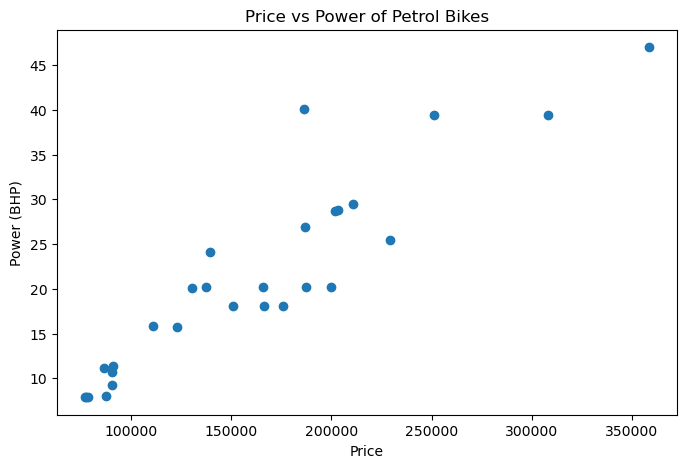

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    petrol_df["Price"],
    petrol_df["Power_BHP"]
)

plt.xlabel("Price")
plt.ylabel("Power (BHP)")
plt.title("Price vs Power of Petrol Bikes")

plt.show()

**Observation:**

- The scatter plot shows a positive relationship between price and power. In general, bikes with higher power tend to have higher prices. However, some bikes such as the Bajaj Pulsar NS400Z offer high power at a comparatively lower price.

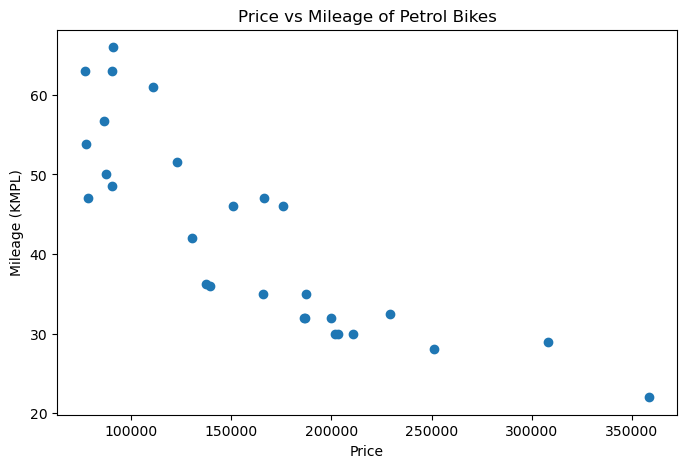

In [93]:
plt.figure(figsize=(8, 5))

plt.scatter(
    petrol_df["Price"],
    petrol_df["Mileage_KMPL"]
)

plt.xlabel("Price")
plt.ylabel("Mileage (KMPL)")
plt.title("Price vs Mileage of Petrol Bikes")

plt.show()

**Observation:**

- The scatter plot shows a negative relationship between price and mileage. In general, lower-priced bikes tend to provide better mileage, while higher-priced bikes tend to have lower mileage.

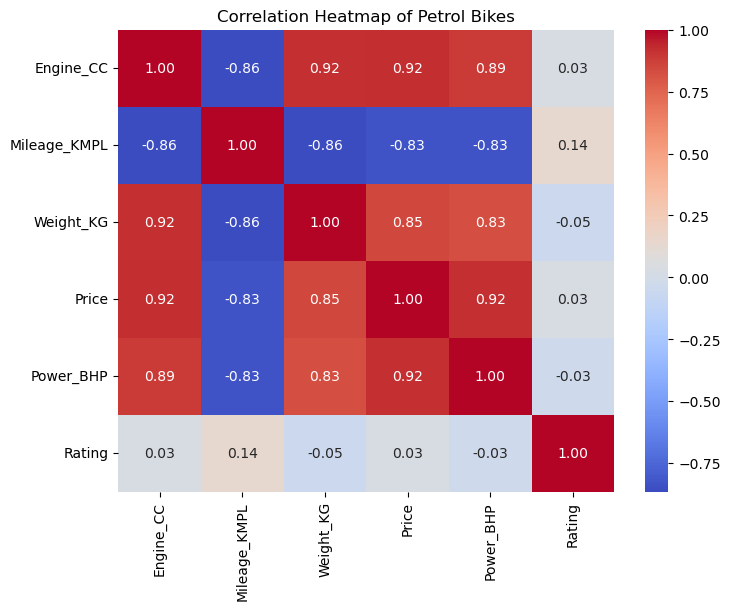

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Petrol Bikes")
plt.show()

**Observation:**

- The correlation heatmap shows strong positive relationships between engine capacity, price, weight, and power. Mileage has a strong negative relationship with engine capacity, price, and power. Customer rating has very little correlation with the technical specifications.

In [95]:
popular_rated = petrol_df.sort_values(
    by=["Rating", "Ratings_Count"],
    ascending=[False, False]
)

print(popular_rated[[
    "Bike_Name",
    "Rating",
    "Ratings_Count",
    "Price",
    "Mileage_KMPL",
    "Power_BHP"
]].head(10).to_string(index=False))

                       Bike_Name  Rating  Ratings_Count  Price  Mileage_KMPL  Power_BHP
                   Yamaha R15 V4     4.8         1546.0 175692          46.0      18.10
              Bajaj Pulsar NS200     4.7         3343.0 139279          36.0      24.13
                    Yamaha MT 15     4.7         1866.0 166400          47.0      18.10
        Royal Enfield Hunter 350     4.7         1785.0 137640          36.2      20.20
        Royal Enfield Bullet 350     4.7         1569.0 165656          35.0      20.20
     Royal Enfield Himalayan 450     4.7          402.0 308029          29.0      39.47
     Royal Enfield Guerrilla 450     4.7           70.0 251063          28.0      39.47
Royal Enfield Continental GT 650     4.7           20.0 358427          22.0      47.00
              Hero Splendor Plus     4.6         4849.0  77123          63.0       7.91
                    Honda SP 125     4.6         4540.0  90636          63.0      10.72


**Observation:** Yamaha R15 V4 has the highest rating of 4.8. Bajaj Pulsar NS200 has a strong 4.7 rating along with the highest ratings count among the 4.7-rated bikes, indicating strong customer engagement. Hero Splendor Plus and Honda SP 125 also show high ratings with large numbers of customer ratings.

In [96]:
value_df = petrol_df.copy()

value_df["Power_per_Lakh"] = (
    value_df["Power_BHP"] / (value_df["Price"] / 100000)
)

best_value = value_df.sort_values(
    by="Power_per_Lakh",
    ascending=False
)

print(best_value[[
    "Bike_Name",
    "Price",
    "Power_BHP",
    "Power_per_Lakh",
    "Rating"
]].head(10).to_string(index=False))

                  Bike_Name  Price  Power_BHP  Power_per_Lakh  Rating
        Bajaj Pulsar NS400Z 186150      40.04       21.509535     4.5
         Bajaj Pulsar NS200 139279      24.13       17.324938     4.7
Royal Enfield Guerrilla 450 251063      39.47       15.721154     4.7
                  TVS Ronin 130314      20.10       15.424283     4.6
   Royal Enfield Hunter 350 137640      20.20       14.675966     4.7
           Jawa All Star 42 186913      26.94       14.413123     2.5
         TVS Apache RTR 160 110781      15.82       14.280427     4.5
             Yezdi Roadster 201940      28.70       14.212142     4.5
       Jawa All Stars 42 FJ 203529      28.77       14.135578     3.8
   Jawa All Stars 42 Bobber 210979      29.51       13.987174     4.2


**Observation:**
- Bajaj Pulsar NS400Z provides the highest power-to-price value at 21.51 BHP per ₹1 lakh, followed by Bajaj Pulsar NS200 at 17.32 BHP per ₹1 lakh. This indicates that some mid-priced bikes can provide better power value than more expensive bikes.

In [97]:
value_df["Mileage_per_Lakh"] = (
    value_df["Mileage_KMPL"] / (value_df["Price"] / 100000)
)

best_mileage_value = value_df.sort_values(
    by="Mileage_per_Lakh",
    ascending=False
)

print(best_mileage_value[[
    "Bike_Name",
    "Price",
    "Mileage_KMPL",
    "Mileage_per_Lakh",
    "Rating"
]].head(10).to_string(index=False))

           Bike_Name  Price  Mileage_KMPL  Mileage_per_Lakh  Rating
  Hero Splendor Plus  77123         63.00         81.687694     4.6
    Hero Xtreme 125R  91000         66.00         72.527473     4.6
         TVS Jupiter  77352         53.84         69.603889     4.5
        Honda SP 125  90636         63.00         69.508804     4.6
      TVS Raider 125  86397         56.70         65.627279     4.4
     Honda Activa 6G  78687         47.00         59.730324     4.4
     TVS Jupiter 125  87469         50.00         57.163109     4.1
  TVS Apache RTR 160 110781         61.00         55.063594     4.5
       TVS Ntorq 125  90558         48.50         53.556837     4.4
Bajaj Pulsar N160 2V 122990         51.60         41.954630     4.6


**Observation:**
- Hero Splendor Plus provides the highest mileage-to-price value at 81.69 KMPL per ₹1 lakh, followed by Hero Xtreme 125R at 72.53 KMPL per ₹1 lakh. This indicates that affordable bikes can provide better mileage value compared with more expensive bikes.

In [98]:
score_df = petrol_df.copy()

score_df["Rating_Score"] = score_df["Rating"] / score_df["Rating"].max()
score_df["Mileage_Score"] = score_df["Mileage_KMPL"] / score_df["Mileage_KMPL"].max()
score_df["Power_Score"] = score_df["Power_BHP"] / score_df["Power_BHP"].max()
score_df["Price_Score"] = score_df["Price"].min() / score_df["Price"]
score_df["Weight_Score"] = score_df["Weight_KG"].min() / score_df["Weight_KG"]

score_df["Overall_Score"] = (
    score_df["Rating_Score"] * 0.25 +
    score_df["Mileage_Score"] * 0.20 +
    score_df["Power_Score"] * 0.20 +
    score_df["Price_Score"] * 0.20 +
    score_df["Weight_Score"] * 0.15
)

best_bikes = score_df.sort_values(
    by="Overall_Score",
    ascending=False
)

print(best_bikes[[
    "Bike_Name",
    "Rating",
    "Mileage_KMPL",
    "Power_BHP",
    "Price",
    "Weight_KG",
    "Overall_Score"
]].head(10).to_string(index=False))

           Bike_Name  Rating  Mileage_KMPL  Power_BHP  Price  Weight_KG  Overall_Score
  Hero Splendor Plus     4.6         63.00       7.91  77123      112.0       0.804777
        Honda SP 125     4.6         63.00      10.72  90636      116.0       0.782067
         TVS Jupiter     4.5         53.84       7.91  77352      105.0       0.780594
    Hero Xtreme 125R     4.6         66.00      11.40  91000      136.0       0.773404
      TVS Raider 125     4.4         56.70      11.20  86397      123.0       0.755225
     Honda Activa 6G     4.4         47.00       7.88  78687      106.0       0.749732
  TVS Apache RTR 160     4.5         61.00      15.82 110781      137.0       0.740741
       TVS Ntorq 125     4.4         48.50       9.25  90558      111.0       0.727718
     TVS Jupiter 125     4.1         50.00       8.04  87469      108.0       0.721447
Bajaj Pulsar N160 2V     4.6         51.60      15.68 122990      148.0       0.694503


**Observation:**
- Based on the weighted multi-feature scoring approach, Hero Splendor Plus ranks first with an overall score of 0.805, followed by Honda SP 125 with 0.782 and TVS Jupiter with 0.781. The scoring indicates that affordable, lightweight, fuel-efficient bikes with good customer ratings perform strongly under the selected criteria.

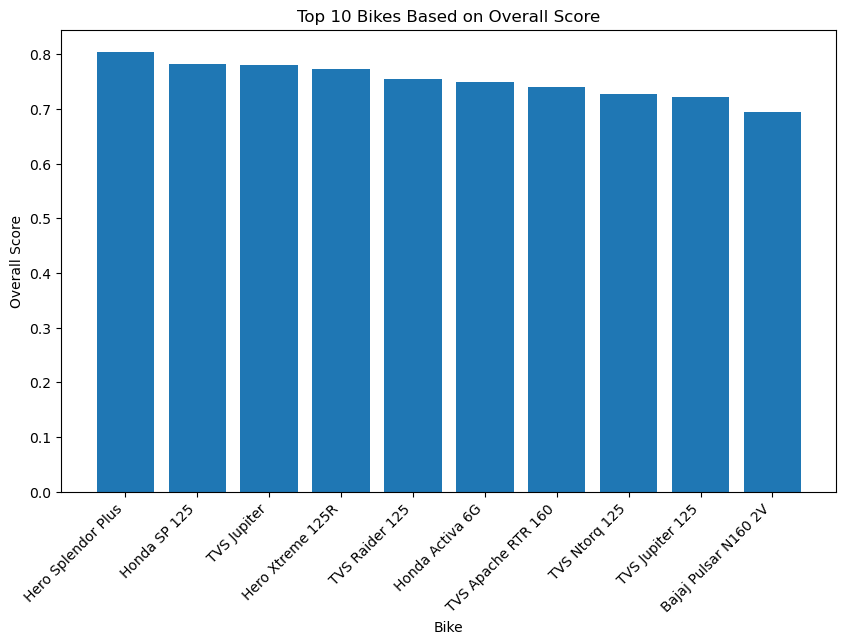

In [99]:
top_10_bikes = best_bikes.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_bikes["Bike_Name"],
    top_10_bikes["Overall_Score"]
)

plt.xlabel("Bike")
plt.ylabel("Overall Score")
plt.title("Top 10 Bikes Based on Overall Score")

plt.xticks(rotation=45, ha="right")

plt.show()

**Observation:**
- The bar chart shows the top 10 bikes based on the overall weighted score. Hero Splendor Plus ranks first with a score of 0.805, followed by Honda SP 125 and TVS Jupiter. The results indicate that bikes with a good balance of affordability, mileage, rating, power, and weight perform better under the selected scoring criteria.

In [100]:
print("Best Rated Bike:")
print(petrol_df.loc[petrol_df["Rating"].idxmax(), 
                    ["Bike_Name", "Rating"]])

print("\nBest Mileage Bike:")
print(petrol_df.loc[petrol_df["Mileage_KMPL"].idxmax(), 
                    ["Bike_Name", "Mileage_KMPL"]])

print("\nMost Powerful Bike:")
print(petrol_df.loc[petrol_df["Power_BHP"].idxmax(), 
                    ["Bike_Name", "Power_BHP"]])

print("\nLowest Price Bike:")
print(petrol_df.loc[petrol_df["Price"].idxmin(), 
                    ["Bike_Name", "Price"]])

print("\nLightest Bike:")
print(petrol_df.loc[petrol_df["Weight_KG"].idxmin(), 
                    ["Bike_Name", "Weight_KG"]])

Best Rated Bike:
Bike_Name    Yamaha R15 V4
Rating                 4.8
Name: 16, dtype: object

Best Mileage Bike:
Bike_Name       Hero Xtreme 125R
Mileage_KMPL                66.0
Name: 12, dtype: object

Most Powerful Bike:
Bike_Name    Royal Enfield Continental GT 650
Power_BHP                                47.0
Name: 15, dtype: object

Lowest Price Bike:
Bike_Name    Hero Splendor Plus
Price                     77123
Name: 24, dtype: object

Lightest Bike:
Bike_Name    TVS Jupiter
Weight_KG          105.0
Name: 18, dtype: object


**Observation:**
- Yamaha R15 V4 has the highest customer rating at 4.8. Hero Xtreme 125R provides the highest mileage at 66 KMPL. Royal Enfield Continental GT 650 is the most powerful bike with 47 BHP. Hero Splendor Plus is the lowest-priced bike at ₹77,123, while TVS Jupiter is the lightest bike at 105 kg. This shows that different bikes perform best in different feature categories.

In [101]:
df_clean.to_csv("BikeWale_Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Cleaned dataset saved successfully!
Rows: 30
Columns: 9


In [102]:
print(df_clean.to_string(index=False))

                       Bike_Name  Engine_CC  Mileage_KMPL  Weight_KG  Price  Power_BHP  Rating  Ratings_Count Vehicle_Type
            Bajaj Pulsar N160 2V     164.82         51.60      148.0 122990      15.68     4.6         1277.0       Petrol
                  TVS Raider 125     124.80         56.70      123.0  86397      11.20     4.4         2955.0       Petrol
                       TVS Ronin     225.90         42.00      160.0 130314      20.10     4.6         1154.0       Petrol
     Royal Enfield Himalayan 440     443.00         32.50      199.0 229000      25.40     4.6           18.0       Petrol
                       TVS iQube        NaN           NaN      115.0 119250        NaN     3.6          878.0     Electric
        Royal Enfield Hunter 350     349.34         36.20      181.0 137640      20.20     4.7         1785.0       Petrol
                    Honda SP 125     123.94         63.00      116.0  90636      10.72     4.6         4540.0       Petrol
       Royal Enf

In [103]:
insights = pd.DataFrame({
    "Category": [
        "Highest Rated",
        "Highest Mileage",
        "Highest Power",
        "Lowest Price",
        "Lightest",
        "Overall Best"
    ],
    "Bike": [
        petrol_df.loc[petrol_df["Rating"].idxmax(), "Bike_Name"],
        petrol_df.loc[petrol_df["Mileage_KMPL"].idxmax(), "Bike_Name"],
        petrol_df.loc[petrol_df["Power_BHP"].idxmax(), "Bike_Name"],
        petrol_df.loc[petrol_df["Price"].idxmin(), "Bike_Name"],
        petrol_df.loc[petrol_df["Weight_KG"].idxmin(), "Bike_Name"],
        best_bikes.iloc[0]["Bike_Name"]
    ],
    "Value": [
        petrol_df["Rating"].max(),
        petrol_df["Mileage_KMPL"].max(),
        petrol_df["Power_BHP"].max(),
        petrol_df["Price"].min(),
        petrol_df["Weight_KG"].min(),
        round(best_bikes.iloc[0]["Overall_Score"], 3)
    ]
})

print(insights.to_string(index=False))

       Category                             Bike     Value
  Highest Rated                    Yamaha R15 V4     4.800
Highest Mileage                 Hero Xtreme 125R    66.000
  Highest Power Royal Enfield Continental GT 650    47.000
   Lowest Price               Hero Splendor Plus 77123.000
       Lightest                      TVS Jupiter   105.000
   Overall Best               Hero Splendor Plus     0.805


**Observation:**
- The analysis identifies different bikes as leaders across different categories. Yamaha R15 V4 has the highest rating, Hero Xtreme 125R has the highest mileage, and Royal Enfield Continental GT 650 has the highest power. Hero Splendor Plus has the lowest price and also achieves the highest overall score, making it the best-performing bike under the selected weighted criteria.

In [104]:
recommendations = [
    "Recommend Hero Splendor Plus for budget-conscious customers seeking a balance of price, mileage, rating, and weight.",
    "Recommend Hero Xtreme 125R for customers who prioritize fuel efficiency.",
    "Recommend Yamaha R15 V4 for customers who prioritize customer ratings and sporty performance.",
    "Recommend Royal Enfield Continental GT 650 for customers who prioritize maximum power.",
    "Recommend TVS Jupiter for customers who prefer a lightweight and affordable option."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

1. Recommend Hero Splendor Plus for budget-conscious customers seeking a balance of price, mileage, rating, and weight.
2. Recommend Hero Xtreme 125R for customers who prioritize fuel efficiency.
3. Recommend Yamaha R15 V4 for customers who prioritize customer ratings and sporty performance.
4. Recommend Royal Enfield Continental GT 650 for customers who prioritize maximum power.
5. Recommend TVS Jupiter for customers who prefer a lightweight and affordable option.


In [105]:
data_dictionary = pd.DataFrame({
    "Column_Name": [
        "Bike_Name",
        "Engine_CC",
        "Mileage_KMPL",
        "Weight_KG",
        "Price",
        "Power_BHP",
        "Rating",
        "Ratings_Count",
        "Vehicle_Type"
    ],
    "Description": [
        "Name of the bike",
        "Engine capacity of the bike in cubic centimeters",
        "Mileage of the bike in kilometers per litre",
        "Kerb weight of the bike in kilograms",
        "Displayed bike price in Indian Rupees",
        "Power output of the bike in brake horsepower",
        "Customer rating of the bike",
        "Number of customer ratings available on BikeWale",
        "Type of vehicle: Petrol or Electric"
    ]
})

print(data_dictionary.to_string(index=False))

  Column_Name                                      Description
    Bike_Name                                 Name of the bike
    Engine_CC Engine capacity of the bike in cubic centimeters
 Mileage_KMPL      Mileage of the bike in kilometers per litre
    Weight_KG             Kerb weight of the bike in kilograms
        Price            Displayed bike price in Indian Rupees
    Power_BHP     Power output of the bike in brake horsepower
       Rating                      Customer rating of the bike
Ratings_Count Number of customer ratings available on BikeWale
 Vehicle_Type              Type of vehicle: Petrol or Electric


In [106]:
data_dictionary.to_csv("BikeWale_Data_Dictionary.csv", index=False)

print("Data Dictionary saved successfully!")
print("Rows:", data_dictionary.shape[0])
print("Columns:", data_dictionary.shape[1])

Data Dictionary saved successfully!
Rows: 9
Columns: 2


In [107]:
cleaning_documentation = pd.DataFrame({
    "Cleaning_Step": [
        "Duplicate Check",
        "Duplicate Bike Name Check",
        "Data Type Check",
        "Missing Value Check",
        "Invalid Value Check",
        "Vehicle Type Classification",
        "Missing Ratings Count",
        "Missing EV Specifications"
    ],
    "Action_Taken": [
        "Checked for duplicate rows; no duplicates found.",
        "Checked for duplicate bike names; no duplicates found.",
        "Verified numeric and text columns have appropriate data types.",
        "Identified missing values in some technical specifications.",
        "Checked numerical columns for zero or negative values; none found.",
        "Classified bikes as Petrol or Electric.",
        "Kept missing ratings counts as NaN where BikeWale did not provide the count.",
        "Kept missing Engine, Mileage and Power values for electric bikes because these specifications are not directly applicable."
    ]
})

print(cleaning_documentation.to_string(index=False))

              Cleaning_Step                                                                                                               Action_Taken
            Duplicate Check                                                                           Checked for duplicate rows; no duplicates found.
  Duplicate Bike Name Check                                                                     Checked for duplicate bike names; no duplicates found.
            Data Type Check                                                             Verified numeric and text columns have appropriate data types.
        Missing Value Check                                                                Identified missing values in some technical specifications.
        Invalid Value Check                                                         Checked numerical columns for zero or negative values; none found.
Vehicle Type Classification                                                                   

In [108]:
cleaning_documentation.to_csv(
    "BikeWale_Data_Cleaning_Documentation.csv",
    index=False
)

print("Cleaning documentation saved successfully!")
print("Rows:", cleaning_documentation.shape[0])
print("Columns:", cleaning_documentation.shape[1])

Cleaning documentation saved successfully!
Rows: 8
Columns: 2


In [109]:
project_summary = pd.DataFrame({
    "Project_Section": [
        "Website",
        "Project Objective",
        "Dataset Size",
        "Vehicle Types",
        "Highest Rated Bike",
        "Highest Mileage Bike",
        "Most Powerful Bike",
        "Lowest Priced Bike",
        "Lightest Bike",
        "Overall Best Bike"
    ],
    "Details": [
        "BikeWale",
        "Analysis on finding out the best bikes in India based on their features",
        "30 bikes and 9 columns",
        "28 Petrol and 2 Electric",
        "Yamaha R15 V4 - 4.8 rating",
        "Hero Xtreme 125R - 66 KMPL",
        "Royal Enfield Continental GT 650 - 47 BHP",
        "Hero Splendor Plus - ₹77,123",
        "TVS Jupiter - 105 kg",
        "Hero Splendor Plus - Overall Score 0.805"
    ]
})

print(project_summary.to_string(index=False))

     Project_Section                                                                 Details
             Website                                                                BikeWale
   Project Objective Analysis on finding out the best bikes in India based on their features
        Dataset Size                                                  30 bikes and 9 columns
       Vehicle Types                                                28 Petrol and 2 Electric
  Highest Rated Bike                                              Yamaha R15 V4 - 4.8 rating
Highest Mileage Bike                                              Hero Xtreme 125R - 66 KMPL
  Most Powerful Bike                               Royal Enfield Continental GT 650 - 47 BHP
  Lowest Priced Bike                                            Hero Splendor Plus - ₹77,123
       Lightest Bike                                                    TVS Jupiter - 105 kg
   Overall Best Bike                                Hero Splendor Plus

In [110]:
project_summary.to_csv(
    "BikeWale_Project_Summary.csv",
    index=False
)

print("Project summary saved successfully!")
print("Rows:", project_summary.shape[0])
print("Columns:", project_summary.shape[1])

Project summary saved successfully!
Rows: 10
Columns: 2


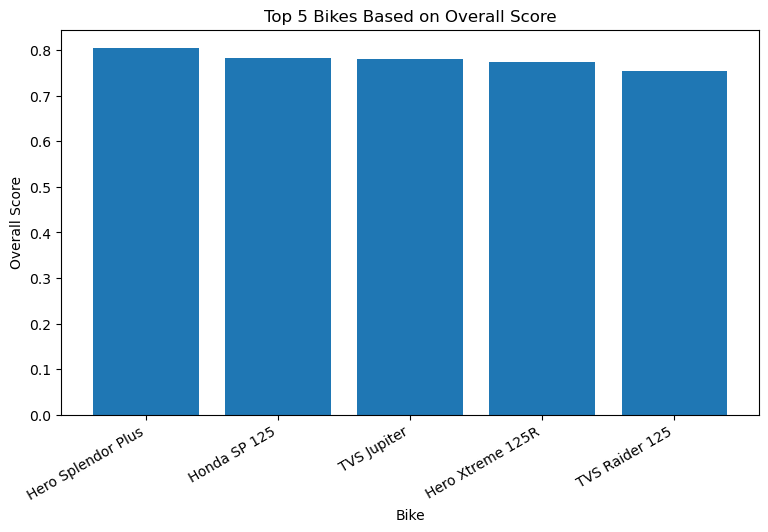

In [111]:
top_5 = best_bikes.head(5)

plt.figure(figsize=(9, 5))

plt.bar(
    top_5["Bike_Name"],
    top_5["Overall_Score"]
)

plt.xlabel("Bike")
plt.ylabel("Overall Score")
plt.title("Top 5 Bikes Based on Overall Score")

plt.xticks(rotation=30, ha="right")

plt.show()

**Observation:**
- The comparison shows that Hero Splendor Plus ranks first among the top five bikes based on the overall weighted score, followed by Honda SP 125 and TVS Jupiter. These bikes demonstrate a strong balance of price, mileage, rating, power, and weight under the selected scoring criteria.

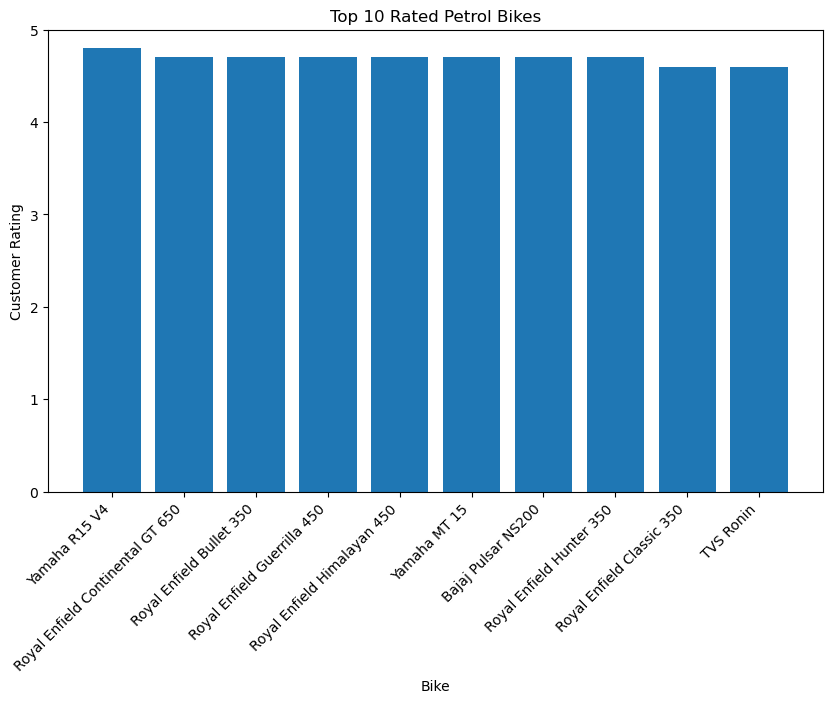

In [112]:
top_10_rated = petrol_df.sort_values(
    by="Rating",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_rated["Bike_Name"],
    top_10_rated["Rating"]
)

plt.xlabel("Bike")
plt.ylabel("Customer Rating")
plt.title("Top 10 Rated Petrol Bikes")

plt.xticks(rotation=45, ha="right")

plt.ylim(0, 5)

plt.show()

**Observation:**
- The chart shows the top 10 highest-rated petrol bikes in the dataset. Yamaha R15 V4 has the highest customer rating of 4.8, while several bikes have a rating of 4.7. This indicates strong customer satisfaction among the top-rated bikes in the dataset.

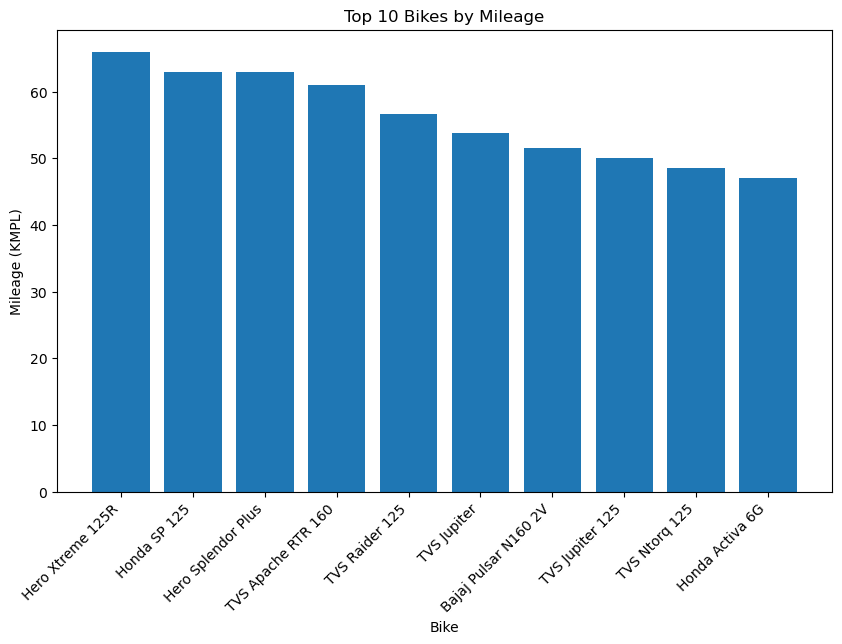

In [113]:
top_10_mileage = petrol_df.sort_values(
    by="Mileage_KMPL",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_mileage["Bike_Name"],
    top_10_mileage["Mileage_KMPL"]
)

plt.xlabel("Bike")
plt.ylabel("Mileage (KMPL)")
plt.title("Top 10 Bikes by Mileage")

plt.xticks(rotation=45, ha="right")

plt.show()

**Observation:**
- The chart shows the top 10 bikes based on mileage. Hero Xtreme 125R has the highest mileage at 66 KMPL, followed by Hero Splendor Plus and Honda SP 125 at 63 KMPL. This indicates that smaller-engine bikes in the dataset generally provide better fuel efficiency.

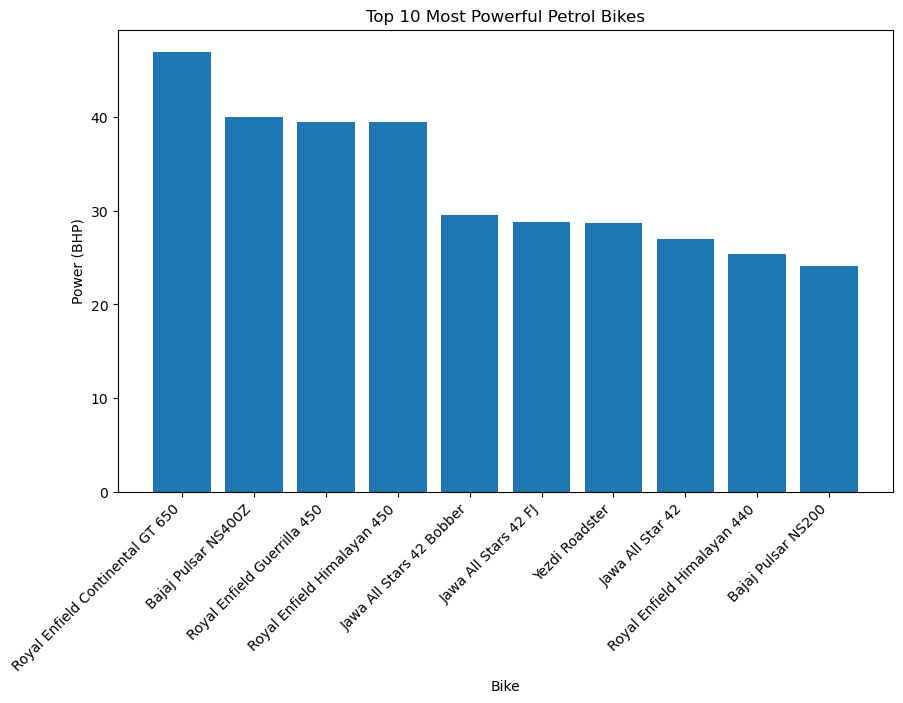

In [114]:
top_10_power = petrol_df.sort_values(
    by="Power_BHP",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_power["Bike_Name"],
    top_10_power["Power_BHP"]
)

plt.xlabel("Bike")
plt.ylabel("Power (BHP)")
plt.title("Top 10 Most Powerful Petrol Bikes")

plt.xticks(rotation=45, ha="right")

plt.show()

**Observation:**
- The chart shows the top 10 most powerful petrol bikes in the dataset. Royal Enfield Continental GT 650 has the highest power at 47 BHP, followed by Bajaj Pulsar NS400Z at 40.04 BHP. The analysis shows that higher-powered bikes generally have larger engine capacities and are positioned at higher price levels.

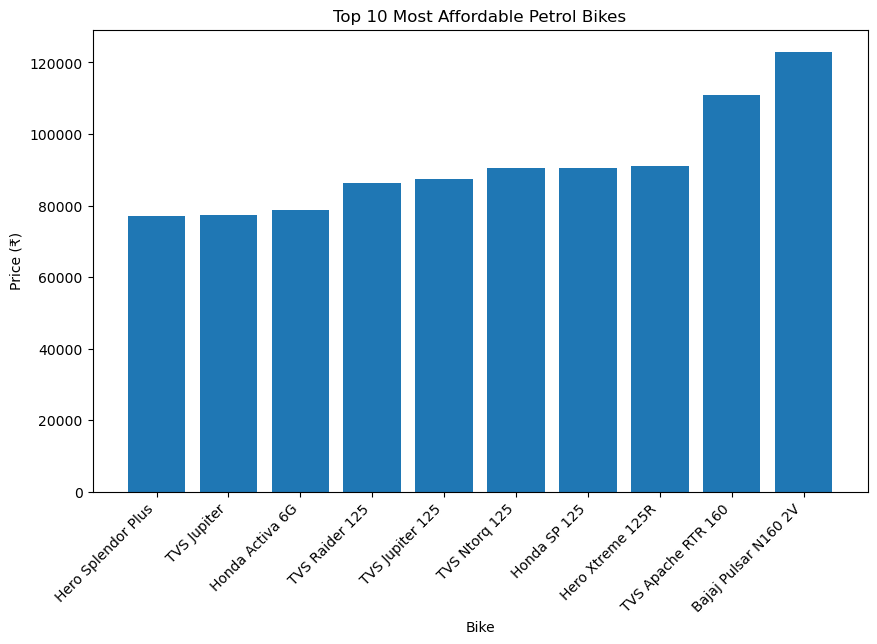

In [115]:
top_10_cheapest = petrol_df.sort_values(
    by="Price",
    ascending=True
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_cheapest["Bike_Name"],
    top_10_cheapest["Price"]
)

plt.xlabel("Bike")
plt.ylabel("Price (₹)")
plt.title("Top 10 Most Affordable Petrol Bikes")

plt.xticks(rotation=45, ha="right")

plt.show()

**Observation:**
- The chart shows the 10 most affordable petrol bikes in the dataset. Hero Splendor Plus has the lowest displayed price at ₹77,123, followed by TVS Jupiter and Honda Activa 6G. These bikes are suitable options for budget-conscious customers.

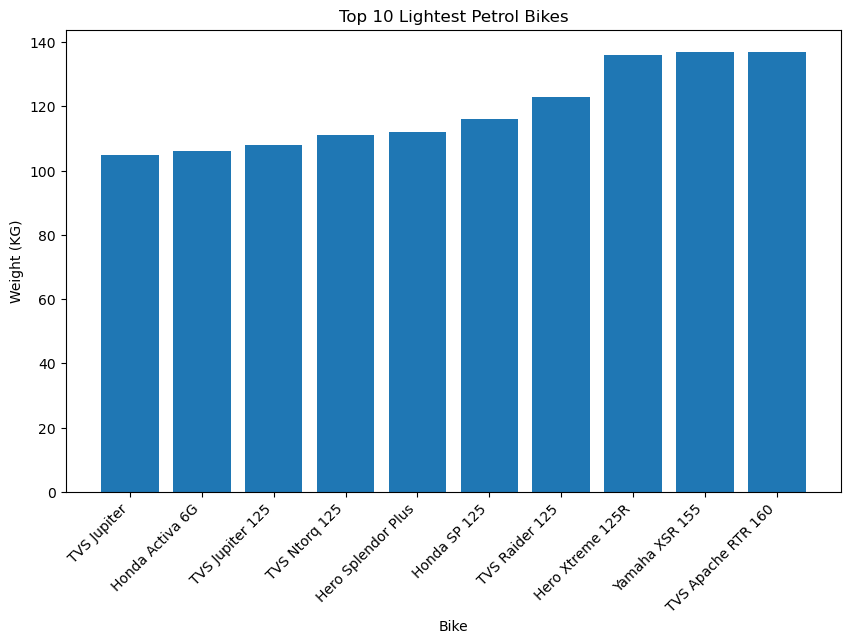

In [116]:
top_10_lightest = petrol_df.sort_values(
    by="Weight_KG",
    ascending=True
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_lightest["Bike_Name"],
    top_10_lightest["Weight_KG"]
)

plt.xlabel("Bike")
plt.ylabel("Weight (KG)")
plt.title("Top 10 Lightest Petrol Bikes")

plt.xticks(rotation=45, ha="right")

plt.show()

**Observation:**
- TVS Jupiter is the lightest petrol bike in the dataset at 105 kg. Honda Activa 6G and TVS Jupiter 125 are also among the lightest bikes. Lightweight bikes may be more convenient for customers who prioritize easy handling.

In [117]:
final_ranking = best_bikes[[
    "Bike_Name",
    "Overall_Score",
    "Rating",
    "Mileage_KMPL",
    "Power_BHP",
    "Price",
    "Weight_KG"
]].head(10)

print(final_ranking.to_string(index=False))

           Bike_Name  Overall_Score  Rating  Mileage_KMPL  Power_BHP  Price  Weight_KG
  Hero Splendor Plus       0.804777     4.6         63.00       7.91  77123      112.0
        Honda SP 125       0.782067     4.6         63.00      10.72  90636      116.0
         TVS Jupiter       0.780594     4.5         53.84       7.91  77352      105.0
    Hero Xtreme 125R       0.773404     4.6         66.00      11.40  91000      136.0
      TVS Raider 125       0.755225     4.4         56.70      11.20  86397      123.0
     Honda Activa 6G       0.749732     4.4         47.00       7.88  78687      106.0
  TVS Apache RTR 160       0.740741     4.5         61.00      15.82 110781      137.0
       TVS Ntorq 125       0.727718     4.4         48.50       9.25  90558      111.0
     TVS Jupiter 125       0.721447     4.1         50.00       8.04  87469      108.0
Bajaj Pulsar N160 2V       0.694503     4.6         51.60      15.68 122990      148.0


**Observation:**
- The overall ranking combines rating, mileage, power, price, and weight using the selected weighted scoring method. Hero Splendor Plus ranks first with an overall score of 0.805, followed by Honda SP 125 and TVS Jupiter.

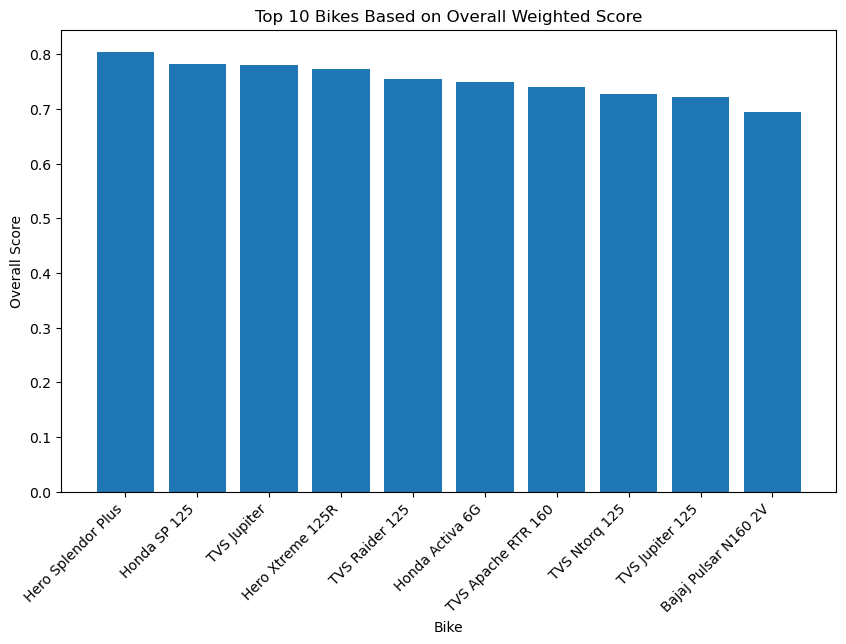

In [118]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_ranking["Bike_Name"],
    final_ranking["Overall_Score"]
)

plt.xlabel("Bike")
plt.ylabel("Overall Score")
plt.title("Top 10 Bikes Based on Overall Weighted Score")

plt.xticks(rotation=45, ha="right")

plt.show()

**Observation:**
- The chart compares the top 10 bikes based on their overall weighted scores. Hero Splendor Plus achieves the highest score, indicating the strongest overall balance of the selected features within this dataset.

In [119]:
business_insights = [
    "Hero Splendor Plus ranks first based on the overall weighted feature score.",
    "Yamaha R15 V4 has the highest customer rating at 4.8.",
    "Hero Xtreme 125R provides the highest mileage at 66 KMPL.",
    "Royal Enfield Continental GT 650 delivers the highest power at 47 BHP.",
    "Hero Splendor Plus is the lowest-priced petrol bike at ₹77,123.",
    "TVS Jupiter is the lightest petrol bike at 105 kg.",
    "Higher engine capacity and power are generally associated with higher prices.",
    "Mileage generally decreases as engine capacity and power increase.",
    "Customer ratings show very little correlation with technical specifications.",
    "Bajaj Pulsar NS400Z provides strong power-to-price value among the analysed bikes."
]

for i, insight in enumerate(business_insights, 1):
    print(f"{i}. {insight}")

1. Hero Splendor Plus ranks first based on the overall weighted feature score.
2. Yamaha R15 V4 has the highest customer rating at 4.8.
3. Hero Xtreme 125R provides the highest mileage at 66 KMPL.
4. Royal Enfield Continental GT 650 delivers the highest power at 47 BHP.
5. Hero Splendor Plus is the lowest-priced petrol bike at ₹77,123.
6. TVS Jupiter is the lightest petrol bike at 105 kg.
7. Higher engine capacity and power are generally associated with higher prices.
8. Mileage generally decreases as engine capacity and power increase.
9. Customer ratings show very little correlation with technical specifications.
10. Bajaj Pulsar NS400Z provides strong power-to-price value among the analysed bikes.


In [120]:
final_recommendations = [
    "Recommend Hero Splendor Plus for customers looking for an affordable and balanced bike.",
    "Recommend Hero Xtreme 125R for customers who prioritize fuel efficiency.",
    "Recommend Yamaha R15 V4 for customers who prioritize high customer ratings and sporty performance.",
    "Recommend Royal Enfield Continental GT 650 for customers who prioritize maximum power.",
    "Recommend TVS Jupiter for customers who prefer a lightweight and affordable option.",
    "Use the weighted scoring approach to compare bikes across multiple features rather than relying on a single specification.",
    "For future analysis, collect a larger number of bikes to improve the representativeness of the results.",
    "Separate electric and petrol bikes when comparing technical specifications because their specifications are not directly comparable."
]

for i, recommendation in enumerate(final_recommendations, 1):
    print(f"{i}. {recommendation}")

1. Recommend Hero Splendor Plus for customers looking for an affordable and balanced bike.
2. Recommend Hero Xtreme 125R for customers who prioritize fuel efficiency.
3. Recommend Yamaha R15 V4 for customers who prioritize high customer ratings and sporty performance.
4. Recommend Royal Enfield Continental GT 650 for customers who prioritize maximum power.
5. Recommend TVS Jupiter for customers who prefer a lightweight and affordable option.
6. Use the weighted scoring approach to compare bikes across multiple features rather than relying on a single specification.
7. For future analysis, collect a larger number of bikes to improve the representativeness of the results.
8. Separate electric and petrol bikes when comparing technical specifications because their specifications are not directly comparable.


In [121]:
final_report = pd.DataFrame({
    "Section": [
        "Website",
        "Objective",
        "Dataset",
        "Data Collection",
        "Data Cleaning",
        "EDA",
        "Visualization",
        "Overall Best Bike",
        "Business Insights",
        "Recommendations"
    ],
    "Details": [
        "BikeWale",
        "Analysis on finding out the best bikes in India based on their features",
        "30 bikes with 9 attributes",
        "Python Requests, BeautifulSoup and Regex",
        "Duplicates, data types, missing values and invalid values were checked",
        "Rating, mileage, power, price, weight, value analysis and correlation",
        "Bar charts, scatter plots and correlation heatmap",
        "Hero Splendor Plus based on the selected weighted scoring method",
        "Different bikes perform best in different feature categories",
        "Recommend bikes according to customer priorities such as price, mileage, rating and power"
    ]
})

print(final_report.to_string(index=False))

          Section                                                                                   Details
          Website                                                                                  BikeWale
        Objective                   Analysis on finding out the best bikes in India based on their features
          Dataset                                                                30 bikes with 9 attributes
  Data Collection                                                  Python Requests, BeautifulSoup and Regex
    Data Cleaning                    Duplicates, data types, missing values and invalid values were checked
              EDA                     Rating, mileage, power, price, weight, value analysis and correlation
    Visualization                                         Bar charts, scatter plots and correlation heatmap
Overall Best Bike                          Hero Splendor Plus based on the selected weighted scoring method
Business Insights           

In [122]:
final_report.to_csv(
    "BikeWale_Final_Project_Report.csv",
    index=False
)

print("Final project report data saved successfully!")

Final project report data saved successfully!


In [123]:
final_ranking.to_csv(
    "BikeWale_Final_Bike_Ranking.csv",
    index=False
)

print("Final bike ranking saved successfully!")

Final bike ranking saved successfully!


In [124]:
business_insights_df = pd.DataFrame({
    "Business_Insights": business_insights
})

business_insights_df.to_csv(
    "BikeWale_Business_Insights.csv",
    index=False
)

print("Business insights saved successfully!")

Business insights saved successfully!


In [125]:
recommendations_df = pd.DataFrame({
    "Recommendations": final_recommendations
})

recommendations_df.to_csv(
    "BikeWale_Recommendations.csv",
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!


**# Conclusion**

This project analyzed bike data collected from BikeWale using Python, Requests, BeautifulSoup, and Regular Expressions.

The dataset contains 30 bikes with information such as engine capacity, mileage, weight, price, power, customer rating, ratings count, and vehicle type.

Through data cleaning, exploratory data analysis, visualization, and weighted feature scoring, different bikes were identified as leaders in different categories.

- Yamaha R15 V4 achieved the highest customer rating of 4.8.
- Hero Xtreme 125R achieved the highest mileage of 66 KMPL.
- Royal Enfield Continental GT 650 achieved the highest power of 47 BHP.
- Hero Splendor Plus had the lowest displayed price of ₹77,123.
- TVS Jupiter was the lightest bike at 105 kg.
- Hero Splendor Plus achieved the highest overall weighted score of 0.805.

Overall, this project demonstrates how web scraping, Regex, data cleaning, EDA, visualization, and data-driven scoring can be used to analyze bike features and support informed purchasing decisions.

**## End of Project**

**Project:** BikeWale Web Scraping & Data Analytics  
**Objective:** Analysis on finding out the best bikes in India based on their features.